<div style="
    border: 2px solid #2c3e50;
    border-radius: 12px;
    padding: 20px;
    background-color: #f8f9fa;
    margin: 10px 0 20px 0;
    box-shadow: 0 2px 8px rgba(0,0,0,0.08);
">

  <h1 style="margin: 0; color: #1f3b73; font-size: 28px;">
    Notebook 09 — Genetic Algorithms for Optimization
  </h1>

  <h2 style="margin: 10px 0 18px 0; color: #34495e; font-size: 20px; font-weight: normal;">
    Python for Operations Research
  </h2>

  <hr style="border: none; border-top: 1px solid #cfd8dc; margin: 15px 0;">

  <p style="margin: 6px 0; font-size: 16px;">
    <b>Amirkabir University of Technology (Tehran Polytechnic)</b>
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Prof:</b> Dr. A. Golroo
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Mentor:</b> Parsa Sadri
  </p>

</div>


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    0. Problem Definition
  </h2>
</div>

Genetic Algorithms (GA) are **metaheuristic optimization methods** inspired by the process of natural evolution.  
They are particularly useful for solving **large-scale and complex optimization problems** where classical exact methods become computationally expensive.

In Operations Research, GA has been successfully applied to problems such as:

- Knapsack Problem
- Traveling Salesman Problem (TSP)
- Scheduling Problems
- Facility Location
- Network Design

Unlike deterministic optimization methods, GA works with a **population of candidate solutions** and iteratively improves them using evolutionary operators such as **selection, crossover, and mutation**.

In this notebook we will:

1. Introduce the core concepts of Genetic Algorithms
2. Implement the GA step by step
3. Apply GA to solve a **Knapsack Optimization Problem**
4. Visualize the convergence behavior of the algorithm

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    1. Biological Inspiration Behind Genetic Algorithms
  </h2>
</div>

Genetic Algorithms mimic the principles of **natural selection**.

Key concepts include:

### Population
A set of candidate solutions.

### Chromosome
A representation of a solution.

### Gene
A component of the chromosome.

### Fitness Function
Measures how good a solution is.

### Evolutionary Operators

Genetic Algorithms evolve solutions using:

- **Selection** → choosing good parents
- **Crossover** → combining parents
- **Mutation** → random variations

General workflow of GA:

$$Initialize Population$$

$$↓$$

$$Evaluate Fitness$$

$$↓$$

$$Selection$$

$$↓$$

$$Crossover$$

$$↓$$

$$Mutation$$

$$↓$$

$$New Generation$$

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    2. Mathematical Formulation of Optimization
  </h2>
</div>

A general optimization problem can be written as:

$$
\max f(x)
$$

subject to:

$$
x \in S
$$

where:

- $f(x)$ is the **objective function**
- $S$ is the **search space**

In Genetic Algorithms:

- solution $x$ → **chromosome**
- objective value $f(x)$ → **fitness**


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    3. Example Optimization Problem
  </h2>
</div>

To understand the algorithm mechanics, we start with a simple optimization problem:

$$
\max f(x) = x^2
$$

where:

$$
0 \le x \le 31
$$

We represent \(x\) using **binary encoding**.

Example:

$x = 13$

binary representation = $01101$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

population_size = 10
chromosome_length = 5

population = np.random.randint(0,2,(population_size,chromosome_length))

population

array([[0, 1, 0, 0, 0],
       [1, 0, 0, 0, 1],
       [0, 0, 0, 0, 1],
       [0, 1, 1, 1, 0],
       [1, 0, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 1, 1, 1],
       [0, 1, 0, 0, 0],
       [0, 0, 1, 1, 1],
       [1, 1, 0, 1, 1]], dtype=int32)

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    4. Decode Chromosomes
  </h2>
</div>

Since chromosomes are binary strings, we must convert them to decimal values to evaluate the objective function.


In [2]:
def decode(chromosome):
    binary_str = ''.join(map(str, chromosome))
    return int(binary_str,2)

decoded = np.array([decode(c) for c in population])

decoded

array([ 8, 17,  1, 14, 23, 31,  7,  8,  7, 27])

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    5. Fitness Evaluation
  </h2>
</div>

The **fitness function** corresponds to the objective function.

$$
f(x) = x^2
$$

Higher fitness values indicate better solutions.


In [3]:
fitness = decoded**2

df = pd.DataFrame({"Chromosome": [ ''.join(map(str,c)) for c in population ], "x": decoded, "Fitness": fitness})
df

,Chromosome,x,Fitness
0,01000,8,64
1,10001,17,289
2,00001,1,1
3,01110,14,196
4,10111,23,529
5,11111,31,961
6,00111,7,49
7,01000,8,64
8,00111,7,49
9,11011,27,729


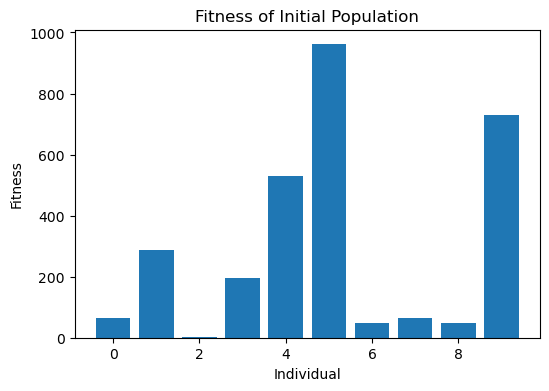

In [4]:
plt.figure(figsize=(6,4))
plt.bar(range(len(fitness)),fitness)
plt.xlabel("Individual")
plt.ylabel("Fitness")
plt.title("Fitness of Initial Population")
plt.show()

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    6. Selection: Roulette Wheel
  </h2>
</div>

Individuals are selected with probability proportional to their fitness.

$$
P_i = \frac{f_i}{\sum f_j}
$$

In [5]:
probabilities = fitness / fitness.sum()

selected_indices = np.random.choice(
    range(population_size),
    size=population_size,
    p=probabilities
)

selected_population = population[selected_indices]

selected_population

array([[1, 1, 0, 1, 1],
       [1, 0, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 0, 0, 0, 1],
       [1, 1, 1, 1, 1],
       [0, 1, 1, 1, 0],
       [1, 0, 0, 0, 1],
       [1, 1, 0, 1, 1],
       [1, 1, 0, 1, 1]], dtype=int32)

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    7. Crossover Operator
  </h2>
</div>

Crossover combines two parent chromosomes to create new offspring.

Here we use **single-point crossover**.


In [6]:
def crossover(parent1,parent2):

    point = np.random.randint(1,chromosome_length-1)

    child1 = np.concatenate([parent1[:point],parent2[point:]])
    child2 = np.concatenate([parent2[:point],parent1[point:]])

    return child1,child2

In [7]:
offspring = []

for i in range(0,population_size,2):

    p1 = selected_population[i]
    p2 = selected_population[i+1]

    c1,c2 = crossover(p1,p2)

    offspring.append(c1)
    offspring.append(c2)

offspring = np.array(offspring)

offspring

array([[1, 1, 1, 1, 1],
       [1, 0, 0, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 0, 0, 0, 1],
       [0, 1, 0, 0, 1],
       [1, 0, 1, 1, 0],
       [1, 1, 0, 1, 1],
       [1, 1, 0, 1, 1]], dtype=int32)

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    8. Mutation Operator
  </h2>
</div>

Mutation randomly flips bits to maintain genetic diversity.

Example:
$$101001 → 101101$$


Mutation probability is typically small.


In [8]:
mutation_rate = 0.05

def mutate(chromosome):

    for i in range(len(chromosome)):
        if np.random.rand() < mutation_rate:
            chromosome[i] = 1 - chromosome[i]

    return chromosome

mutated_population = np.array([mutate(c.copy()) for c in offspring])

mutated_population

array([[1, 1, 1, 1, 1],
       [1, 0, 0, 1, 1],
       [1, 1, 0, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 0, 0, 0, 1],
       [0, 0, 0, 0, 1],
       [0, 0, 1, 1, 0],
       [1, 1, 0, 1, 1],
       [1, 1, 0, 1, 1]], dtype=int32)

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    9. Full Genetic Algorithm
  </h2>
</div>

Now we combine all steps into a full evolutionary process.

Algorithm:

    1- Initialize population  
    2- Evaluate fitness  
    3- Selection  
    4- Crossover  
    5- Mutation  
    6- Repeat for several generations

In [9]:
generations = 50

best_history = []

population = np.random.randint(0,2,(population_size,chromosome_length))

for g in range(generations):

    decoded = np.array([decode(c) for c in population])
    fitness = decoded**2

    best_history.append(fitness.max())

    probabilities = fitness/fitness.sum()

    indices = np.random.choice(range(population_size),population_size,p=probabilities)
    selected = population[indices]

    offspring = []

    for i in range(0,population_size,2):

        p1 = selected[i]
        p2 = selected[i+1]

        c1,c2 = crossover(p1,p2)

        offspring.append(c1)
        offspring.append(c2)

    offspring = np.array(offspring)

    population = np.array([mutate(c.copy()) for c in offspring])

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    10. Convergence Analysis
  </h2>
</div>

The following plot shows how the best fitness evolves across generations.

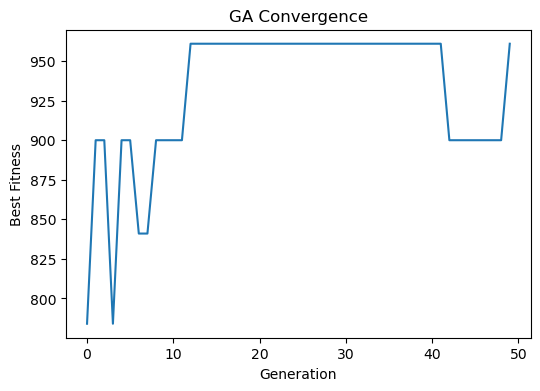

In [10]:
plt.figure(figsize=(6,4))
plt.plot(best_history)
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("GA Convergence")
plt.show()

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    11. Application: Knapsack Optimization
  </h2>
</div>

The **0‑1 Knapsack Problem** is a classic Operations Research optimization problem.

Objective:

$$
\max \sum v_i x_i
$$

subject to:

$$
\sum w_i x_i \le W
$$

where:

- $v_i$ = value of item
- $w_i$ = weight of item
- $x_i \in \{0,1\}$

Each chromosome represents a selection of items.

In [11]:
values = np.array([60,100,120,80,30])
weights = np.array([10,20,30,15,5])

capacity = 50

num_items = len(values)
population_size = 20

In [12]:
def knapsack_fitness(chromosome):

    total_value = np.sum(values*chromosome)
    total_weight = np.sum(weights*chromosome)

    if total_weight > capacity:
        return 0

    return total_value

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    12. Running GA for Knapsack
  </h2>
</div>

In [13]:
generations = 80

population = np.random.randint(0,2,(population_size,num_items))

best_solution = None
best_value = 0

for g in range(generations):

    fitness = np.array([knapsack_fitness(c) for c in population])

    if fitness.max() > best_value:
        best_value = fitness.max()
        best_solution = population[fitness.argmax()]

    probs = fitness + 1
    probs = probs/probs.sum()

    indices = np.random.choice(range(population_size),population_size,p=probs)
    selected = population[indices]

    offspring = []

    for i in range(0,population_size,2):

        p1 = selected[i]
        p2 = selected[i+1]

        point = np.random.randint(1,num_items-1)

        c1 = np.concatenate([p1[:point],p2[point:]])
        c2 = np.concatenate([p2[:point],p1[point:]])

        offspring.append(c1)
        offspring.append(c2)

    population = np.array(offspring)

In [14]:
print("Best Solution:",best_solution)
print("Best Value:",best_value)
print("Total Weight:",np.sum(weights*best_solution))

Best Solution: [1 1 0 1 1]
Best Value: 270
Total Weight: 50
